In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
load_dotenv()

True

In [2]:
# LLM Configuration - DeepSeek R1 Distill Qwen 7B
LLAMA_STUDIO_API_BASE = os.getenv("LLAMA_STUDIO_API_BASE", "http://localhost:1234/v1")
LLAMA_STUDIO_API_KEY = os.getenv("LLAMA_STUDIO_API_KEY", "lm-studio")
LLM_MODEL_NAME = os.getenv("LLM_MODEL_NAME", "deepseek-r1-distill-qwen-7b")
LLM_TEMPERATURE = float(os.getenv("LLM_TEMPERATURE", "0.7"))
LLM_MAX_TOKENS = int(os.getenv("LLM_MAX_TOKENS", "2048"))
LLM_TIMEOUT = int(os.getenv("LLM_TIMEOUT", "60"))  # Timeout in seconds
LLM_MAX_RETRIES = int(os.getenv("LLM_MAX_RETRIES", "2"))  # Number of retries

In [3]:
model = ChatOpenAI(
        base_url=LLAMA_STUDIO_API_BASE,
        api_key=LLAMA_STUDIO_API_KEY,
        model=LLM_MODEL_NAME,
        temperature=LLM_TEMPERATURE,
        max_tokens=LLM_MAX_TOKENS,
        timeout=LLM_TIMEOUT,
        max_retries=LLM_MAX_RETRIES,
      
    )

In [4]:
#define state   
class BlogState(TypedDict):
    title:str
    outline:str
    content:str
    evalaute:str
   
    

In [5]:
def create_outline(state:BlogState) -> BlogState:
    # fecth title 
    title   = state['title']
    # call lllm for outline 
    prompt = f"Generate a detailed outline for the blog on an topic -{title}"
    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

def create_blog(state:BlogState) -> BlogState:
    title   = state['title']
    outline  = state['outline']
    # form a promt
    prompt = f"Write a detailed Blog on the title - {title} using the following Outline \n{outline}"
    content = model.invoke(prompt).content
    state['content'] = content
    return state

def evaluate_blog(state:BlogState) -> BlogState:
    outline  = state['outline']
    blog = state['content']
    prompt = f"Based on these outlines - {outline} Rate my blogs \n{blog} between 1 -10 range"
    evalaute = model.invoke(prompt).content
    state['evalaute'] = evalaute
    return state




In [6]:
# define graph 
graph = StateGraph(BlogState)

# add nodes
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
graph.add_node('evaluate_blog',evaluate_blog)




# add edges to graph 
graph.add_edge(START,'create_outline')

graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog','evaluate_blog')
graph.add_edge('evaluate_blog',END)

#compile the graph 
workflow = graph.compile()

# execute the graph

In [7]:
intital_state = {'title':'Rise of AI in Pakistan'}
final_state = workflow.invoke(intital_state)
print(final_state['outline'])

## Blog Outline: The Rise of AI in Pakistan: Opportunities, Challenges, and Future Potential

**I. Introduction (Approx. 150-200 words)**

*   **Hook:** Start with a compelling statement about AI's growing global impact or a recent news story highlighting AI adoption somewhere in the world.  Example: "Artificial intelligence is rapidly transforming industries worldwide, and Pakistan is poised to be a key player in this revolution."
*   **Briefly Define AI:** Explain what AI is in accessible terms (Machine Learning, Deep Learning, Natural Language Processing). Don't get too technical; focus on the practical applications.
*   **Pakistan's Current AI Landscape:**  Highlight the current state of AI adoption and development in Pakistan - are we lagging or leading? Mention existing initiatives and players (government, startups, academia).
*   **Blog Goal & Roadmap:** Clearly state what the blog post will cover: exploring opportunities, challenges, and future potential. Briefly outline the ke

In [8]:
print(final_state['content'])

## The Rise of AI in Pakistan: Opportunities, Challenges, and Future Potential

**(Image: A modern image depicting technology merging with Pakistani culture – e.g., a digital representation of a farmer using an AI-powered tool in a field.)**

Artificial intelligence is rapidly transforming industries worldwide, and Pakistan is poised to be a key player in this revolution. From self-driving cars to personalized medicine, AI’s influence is undeniable. But what does the future hold for artificial intelligence within Pakistan? This blog post dives deep into the current landscape of AI adoption, explores its immense opportunities, tackles the challenges hindering progress, and envisions the potential for AI to shape Pakistan's future.  We'll cover everything from healthcare advancements to economic growth drivers – painting a comprehensive picture of where Pakistan stands and where it’s headed in this exciting field.



**II. The Current Landscape of AI in Pakistan (Approx. 350 words)**

AI

In [9]:
print(final_state['evalaute'])

## Blog Post Rating: 9.5/10

**Here's a breakdown of why it's so good and areas where it excels:**

**Strengths:**

*   **Comprehensive & Detailed:** The outline is extremely thorough, covering all the necessary aspects of AI in Pakistan – from opportunities to challenges and future potential.  The detail provided throughout the draft makes it highly credible and well-researched.
*   **Well-Structured & Organized:** The logical flow of information is excellent. Each section builds upon the previous one, providing a cohesive narrative. 
*   **Clear & Accessible Language:**  The language used is easy to understand for a general audience, avoiding technical jargon where possible.  It balances accessibility with depth.
*   **Actionable Insights:** The "Call to Action" adds a nice touch and encourages reader engagement.
*   **Addresses Key Considerations:** Includes the crucial reminder about data availability, talent gaps, ethical concerns, and regulatory frameworks – all critical areas fo

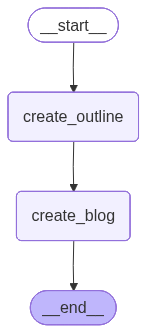

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())